In [ ]:
import dask
dask.config.set(scheduler="synchronous")

# from toolviper.dask.client import local_client

# viper_client = local_client(cores=4, memory_limit="4GB")
# viper_client

## Download Dataset

In [ ]:
from xradio.measurement_set import open_processing_set
from toolviper.utils.data import download, update
update()

download(file="twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")
ps_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")

download(file="twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr")
ps_single_pol_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr")


download(file="3c286_Band6_5chans_lsrk_compare_weights.ps.zarr")
ps_full_pol_xdt = open_processing_set("3c286_Band6_5chans_lsrk_compare_weights.ps.zarr")


ps_xdt.xr_ps.summary()

In [1]:

%load_ext autoreload
%autoreload 2

import dask
dask.config.set(scheduler="synchronous")

import os
import numpy as np
from xradio.measurement_set import open_processing_set
from astroviper.distributed.imaging.image_cube_single_field import image_cube_single_field
from xradio.image import make_empty_sky_image

os.system("rm -rf twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
ps_single_pol_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr")
combined_field_and_source_xds = ps_single_pol_xdt.xr_ps.get_combined_field_and_source_xds()
center_field_name = combined_field_and_source_xds.attrs["center_field_name"]
phase_direction = (
    combined_field_and_source_xds.FIELD_PHASE_CENTER_DIRECTION.sel(
        field_name=center_field_name
    )
)

print(ps_single_pol_xdt.xr_ps.get_freq_axis())

empty_img_xds = make_empty_sky_image(
        phase_center=phase_direction.values,
        image_size=[250,250],
        cell_size=np.array([-0.1,0.1]) * np.pi/(180 * 3600),
        frequency_coords=ps_single_pol_xdt.xr_ps.get_freq_axis().values,
        pol_coords=["I"],
        time_coords=[0],
    )

# image_cube_single_field

imaging_metadata_dict = image_cube_single_field(
    ps_store = "twhya_selfcal_5chans_lsrk_compare_weights.ps.zarr",
    image_store = "twhya_selfcal_5chans_lsrk_compare_weights.img.zarr",
    image_params={
        "image_size": [250, 250],
        "cell_size": np.array([0.1, 0.1]) * np.pi/(180 * 3600),
        "phase_direction": phase_direction.values,
        "frequency_coords": ps_single_pol_xdt.xr_ps.get_freq_axis().values,
        "polarization_coords": ["I","Q"],
        "time_coords": [0],
    },
    # imaging_weights_params={
    #     "weighting": "briggs",
    #     "robust": 0.5,
    # },
    imaging_weights_params={
        "weighting": "natural",
    },
    iteration_control_params={
        "niter": 0,
        "nmajor": 0,
        "threshold": 0.0,
        "gain": 0.1,
        "cyclefactor": 1.5,
        "cycleniter": 10,
    },
    gridder="prolate_spheroidal",
    deconvolver="hogbom",
    fft_padding="1.0",
    scan_intents="OBSERVE_TARGET#ON_SOURCE",
    #image_data_variables_keep=["sky", "point_spread_function", "primary_beam"],
    #image_data_variables_keep=["sky_model", "sky_residual", "sky_deconvolved", "point_spread_function", "primary_beam"],
    image_data_variables_keep=[ "sky", "point_spread_function", "primary_beam"],
    data_group_name="base",
    double_precision=True,
    thread_info=None,
    n_chunks=None,
    overwrite=True,
)

import xarray as xr
img_xds = xr.open_zarr("twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
img_xds

<xarray.DataArray 'frequency' (frequency: 5)> Size: 40B
array([3.727306e+11, 3.727312e+11, 3.727318e+11, 3.727324e+11, 3.727330e+11])
Coordinates:
  * frequency  (frequency) float64 40B 3.727e+11 3.727e+11 ... 3.727e+11
Attributes:
    channel_width:           {'attrs': {'type': 'quantity', 'units': 'Hz'}, '...
    observer:                lsrk
    reference_frequency:     {'attrs': {'observer': 'lsrk', 'type': 'spectral...
    spectral_window_intent:  UNSPECIFIED
    spectral_window_name:    ALMA_RB_07#BB_2#SW-01#FULL_RES_0
    type:                    spectral_coord
    units:                   Hz
[2026-03-02 18:59:00,124]     INFO  graphviper:  Number of frequency chunks: 5 frequency channels: {'frequency': 5} 


INFO:graphviper:Number of frequency chunks: 5 frequency channels: {'frequency': 5}


[2026-03-02 18:59:00,125]     INFO  graphviper:  Number of frequency chunks: 5 


INFO:graphviper:Number of frequency chunks: 5
/Users/jsteeb/Dropbox/viper_dev/xradio/src/xradio/measurement_set/load_processing_set.py:69: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  xr.open_datatree(


$$$$$$$$$$ {'correlated_data': 'VISIBILITY', 'date': '2026-03-02T23:59:00.592876+00:00', 'description': 'Data group created for natural imaging weights with .', 'field_and_source': 'field_and_source_base_xds', 'flag': 'FLAG', 'uvw': 'UVW', 'weight': 'WEIGHT', 'data_group_in_name': 'base', 'weight_imaging': 'WEIGHT', 'data_group_out_name': 'imaging'} ***************
3. $$$$$$$ img_xds  dict_keys(['base', 'single_field'])
##### Data groups in image dict_keys(['base', 'single_field'])
img_xds after loop  dict_keys(['base', 'single_field'])
img_xds  <bound method Mapping.keys of Data variables:
    UV_SAMPLING                (frequency, polarization, u, v) complex128 3MB ...
    UV_SAMPLING_NORMALIZATION  (frequency, polarization) float64 16B 24.73 28.53
    VISIBILITY                 (frequency, polarization, u, v) complex128 3MB ...
    VISIBILITY_NORMALIZATION   (frequency, polarization) float64 16B 24.73 28.53>
*************
********** KeysView(Data variables:
    UV_SAMPLING          

/Users/jsteeb/Dropbox/viper_dev/xradio/src/xradio/measurement_set/load_processing_set.py:69: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  xr.open_datatree(
/Users/jsteeb/Dropbox/viper_dev/xradio/src/xradio/measurement_set/load_processing_set.py:69: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr

********** KeysView(Data variables:
    UV_SAMPLING                (frequency, polarization, u, v) complex128 3MB ...
    UV_SAMPLING_NORMALIZATION  (frequency, polarization) float64 16B 24.73 28.53
    VISIBILITY                 (frequency, polarization, u, v) complex128 3MB ...
    VISIBILITY_NORMALIZATION   (frequency, polarization) float64 16B 24.73 28.53
    PRIMARY_BEAM               (time, frequency, polarization, l, m) float64 1MB ...
    POINT_SPREAD_FUNCTION      (time, frequency, polarization, l, m) float64 1MB ...
    SKY                        (time, frequency, polarization, l, m) float64 1MB ...) **********
dv:  SKY  idx:  (slice(None, None, None), slice(0, 1, None), slice(None, None, None), slice(None, None, None), slice(None, None, None))  size_dict:  Frozen({'time': 1, 'frequency': 1, 'polarization': 2, 'l': 250, 'm': 250, 'beam_params_label': 3, 'u': 300, 'v': 300})
dv:  POINT_SPREAD_FUNCTION  idx:  (slice(None, None, None), slice(0, 1, None), slice(None, None, None),

/Users/jsteeb/Dropbox/viper_dev/xradio/src/xradio/measurement_set/load_processing_set.py:69: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  xr.open_datatree(
/Users/jsteeb/Dropbox/viper_dev/xradio/src/xradio/measurement_set/load_processing_set.py:69: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr

<xarray.Dataset> Size: 16MB
Dimensions:                (time: 1, frequency: 5, polarization: 2, l: 250,
                            m: 250, beam_params_label: 3)
Coordinates:
  * time                   (time) float64 8B 0.0
  * frequency              (frequency) float64 40B 3.727e+11 ... 3.727e+11
    velocity               (frequency) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
  * polarization           (polarization) <U1 8B 'I' 'Q'
  * l                      (l) float64 2kB 6.06e-05 6.012e-05 ... -6.012e-05
  * m                      (m) float64 2kB -6.06e-05 -6.012e-05 ... 6.012e-05
    declination            (l, m) float64 500kB dask.array<chunksize=(125, 250), meta=np.ndarray>
    right_ascension        (l, m) float64 500kB dask.array<chunksize=(125, 250), meta=np.ndarray>
  * beam_params_label      (beam_params_label) <U5 60B 'major' 'minor' 'pa'
Data variables:
    POINT_SPREAD_FUNCTION  (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
    PRIMARY_BEAM           (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
    SKY                    (time, frequency, polarization, l, m) float64 5MB dask.array<chunksize=(1, 1, 2, 250, 250), meta=np.ndarray>
Attributes:
    coordinate_system_info:  {'native_pole_direction': {'attrs': {'frame': 'N...
    data_groups:             {'base': {}}
    type:                    image

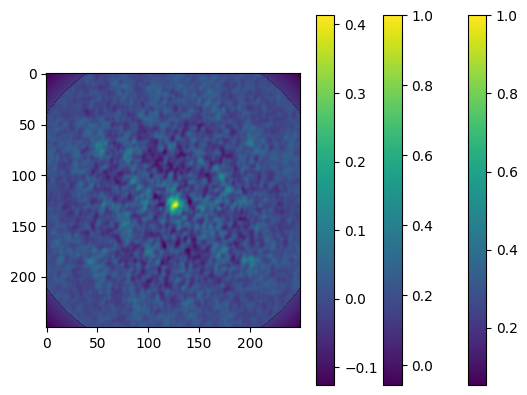

In [5]:
import xarray as xr
img_xds = xr.open_zarr("twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
img_xds

import matplotlib.pyplot as plt
plt.imshow(img_xds.PRIMARY_BEAM.isel(frequency=0, polarization=1, time=0).values)
plt.colorbar()

import matplotlib.pyplot as plt
plt.imshow(img_xds.POINT_SPREAD_FUNCTION.isel(frequency=0, polarization=1, time=0).values)
plt.colorbar()

import matplotlib.pyplot as plt
plt.imshow(img_xds.SKY.isel(frequency=0, polarization=1, time=0).values)
plt.colorbar()

In [ ]:
# from astroviper.task.imaging.calculate_imaging_weights import (
#     calculate_imaging_weights,
# )
from astroviper.task.imaging.calculate_imaging_weights import calculate_imaging_weights
    
#from astroviper.task.imaging.add_uv_sampling_grid import add_uv_sampling_grid_single_field
from xradio.image import make_empty_sky_image
from astroviper.task.imaging.add_visibility_grid import add_visibility_grid_single_field

In [ ]:
{'base': {'correlated_data': 'VISIBILITY', 'date': '2025-09-11T16:50:05.674451+00:00', 'description': "Data group derived from the data column 'VISIBILITY' of an MSv2 converted to MSv4", 'field_and_source': 'field_and_source_base_xds', 'flag': 'FLAG', 'uvw': 'UVW', 'weight': 'WEIGHT'}}


I think the following memory/IO management options cover all the use cases and allow us to experiment (benchmark) with different setups that will inform our architecture. This applies to a single instance of a task in the graph that is processing a partition of the PS data (i.e., a channel chunk).

## Parameters
- `memory_mode = ["in_memory", "in_place", "cache"]`
- `cache_directory = None`
- `write_visibility_model_to_ps = False`
- `write_imaging_weights_to_ps = False`
- `clear_cache = True`

**Core assumption:** The image data partition is always kept in memory until the final image is written to disk.

---

## Memory management modes

### `"in_memory"`
The PS partition is kept entirely in memory.

### `"in_place"`
Only a single MSv4 of the PS partition is kept in memory. Imaging weights and the model are written to the original on-disk PS and removed after imaging, unless `write_visibility_model_to_ps` or `write_imaging_weights_to_ps` is `True`.

In this mode, the visibility data is read in each cycle (higher I/O).

### `"cache"`
Only a single MSv4 of the PS partition is kept in memory. In each cycle, the cache is queried to check whether the relevant partition of the PS is present. If not, the required partition is read from the original PS and written to the cache. The visibility model and imaging weights are always written to the cache.

After imaging, the cache is cleared if `clear_cache` is `True`. In this mode, the visibility data is read in each cycle, but the cache is always checked first. Therefore, if there is a data scatter stage in a workflow, the PS partition will only be read from the cache. This could provide better performance than `"in_place"` if the cache resides on fast local storage.

---

The visibility model or imaging weights can be saved to the original on-disk PS using:
- `write_visibility_model_to_ps`
- `write_imaging_weights_to_ps`

---

## Perfomace

`"in_memory"` > `"cache"` > `"in_place"`

## Expected usage

ALMA should be able to use `memory_mode="in_memory"` in almost all cases, since the PS (visibility data) is smaller than the set of images we need to keep in memory.

ngVLA/VLA may need to use `"in_place"` or `"cache"`, since the PS can be larger than the images that must be kept in memory.

In [ ]:

import xarray as xr
img_xds = xr.open_zarr("twhya_selfcal_5chans_lsrk_compare_weights.img.zarr")
img_xds


import matplotlib.pyplot as plt
plt.imshow(img_xds.SKY.isel(frequency=0, polarization=1, time=0).values)

In [ ]:
from xradio.image import open_image
img_casa_xds = open_image("images_twhya_selfcal_5chans_lsrk/twhya_selfcal_5chans_lsrk_robust_0.5_niter_99.image")
img_casa_xds

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img_casa_xds.SKY.isel(frequency=2, polarization=0, time=0).values)

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
from xradio.measurement_set import open_processing_set
from astroviper.distributed.imaging.image_cube_single_field import image_cube_single_field
from xradio.image import make_empty_sky_image
import xarray as xr 
#ps_single_pol_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr")
ps_single_pol_xdt = xr.open_datatree("twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr", engine="zarr", chunks={})

combined_field_and_source_xds = ps_single_pol_xdt.xr_ps.get_combined_field_and_source_xds()
center_field_name = combined_field_and_source_xds.attrs["center_field_name"]
phase_direction = (
    combined_field_and_source_xds.FIELD_PHASE_CENTER_DIRECTION.sel(
        field_name=center_field_name
    )
)

print(ps_single_pol_xdt.xr_ps.get_freq_axis())

empty_img_xds = make_empty_sky_image(
        phase_center=phase_direction.values,
        image_size=[250,250],
        cell_size=np.array([-0.1,0.1]) * np.pi/(180 * 3600),
        frequency_coords=ps_single_pol_xdt.xr_ps.get_freq_axis().values,
        pol_coords=["I"],
        time_coords=[0],
    )
#Maybe add empty datavariable? (Nans) so that meta data is created. 
empty_img_xds.to_zarr("test.zarr", mode="w")



def write_image_data(input_params):
    #write a chunk (don't use dask here, just write a chunk of data to zarr)
    return 0
    

import dask as da

delayed_list = []
for i in range(5):
    delayed_list.append(da.delayed(write_image_data)({"chunk": i}))
    

da.compute(delayed_list)

empty_img_xds
    
    

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import zarr
import xarray as xr
import dask as da
from numcodecs import Blosc
from xradio.measurement_set import open_processing_set
from xradio.image import make_empty_sky_image

ps_single_pol_xdt = open_processing_set("twhya_selfcal_5chans_lsrk_xx_compare_weights.ps.zarr")
combined_field_and_source_xds = ps_single_pol_xdt.xr_ps.get_combined_field_and_source_xds()
center_field_name = combined_field_and_source_xds.attrs["center_field_name"]
phase_direction = (
    combined_field_and_source_xds.FIELD_PHASE_CENTER_DIRECTION.sel(
        field_name=center_field_name
    )
)

empty_img_xds = make_empty_sky_image(
    phase_center=phase_direction.values,
    image_size=[250, 250],
    cell_size=np.array([-0.1, 0.1]) * np.pi / (180 * 3600),
    frequency_coords=ps_single_pol_xdt.xr_ps.get_freq_axis().values,
    pol_coords=["I"],
    time_coords=[0],
)

n_time = empty_img_xds.sizes["time"]
n_freq = empty_img_xds.sizes["frequency"]
n_pol  = empty_img_xds.sizes["polarization"]
n_l    = empty_img_xds.sizes["l"]
n_m    = empty_img_xds.sizes["m"]

zarr_store_path = "test.zarr"
compressor = Blosc(cname="lz4", clevel=5)  # set to None for no compression

# Step 1: write coordinates and dataset attributes — no data variable, zero RAM
empty_img_xds.to_zarr(zarr_store_path, mode="w")

# Step 2: create the SKY array directly in zarr without allocating any data in memory.
# fill_value=nan is stored only in .zarray metadata; unwritten chunks return nan on read.
# Compressor is also stored in metadata and applied automatically on every subsequent write.
# API differs between zarr v2 (require_dataset / compressor=) and v3 (require_array / compressors=[]).
_ZARR_V3 = int(zarr.__version__.split(".")[0]) >= 3

group = zarr.open_group(zarr_store_path, mode="r+")
_kwargs = dict(
    shape=(n_time, n_freq, n_pol, n_l, n_m),
    chunks=(n_time, 1, n_pol, n_l, n_m),
    dtype=np.float64,
    fill_value=np.nan,
)
if _ZARR_V3:
    sky = group.require_array("SKY", **_kwargs, compressors=[compressor] if compressor else [])
else:
    sky = group.require_dataset("SKY", **_kwargs, compressor=compressor)

# xarray uses _ARRAY_DIMENSIONS to map zarr axes back to named dimensions
sky.attrs["_ARRAY_DIMENSIONS"] = ["time", "frequency", "polarization", "l", "m"]


def write_image_data(input_params):
    """Write one frequency chunk to zarr. No dask, no full-array allocation."""
    chunk_idx  = input_params["chunk"]
    store_path = input_params["store_path"]

    group = zarr.open_group(store_path, mode="r+")
    sky = group["SKY"]

    # Allocate only one chunk worth of memory
    n_time, _, n_pol, n_l, n_m = sky.shape
    data_chunk = np.zeros((n_time, 1, n_pol, n_l, n_m), dtype=np.float64)
    # --- replace with actual imaging computation for this frequency channel ---

    # Slice assignment aligns exactly with one chunk boundary → writes chunk file 0.{chunk_idx}.0.0.0
    # Compressor is applied automatically from the array metadata — no need to pass it here
    sky[:, chunk_idx : chunk_idx + 1, :, :, :] = data_chunk
    return chunk_idx


delayed_list = [
    da.delayed(write_image_data)({"chunk": i, "store_path": zarr_store_path})
    for i in range(n_freq)
]

results = da.compute(*delayed_list)
print("Written chunks:", results)

# Verify xarray can read it back with correct dimension names
zarr.consolidate_metadata(zarr_store_path)
img_xds = xr.open_zarr(zarr_store_path)
img_xds